In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv('C://Users//Prince//Desktop//Ecommerce Project//Sample - Superstore.csv', encoding='latin-1')

In [21]:
# Understand the dataset
# df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
df.head(1)
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [22]:
# Convert date columns to datetime 
df['Order Date'] = pd.to_datetime(df['Order Date'], format = 'mixed')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format = 'mixed')

In [24]:
# Check for missing values
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [25]:
# Drop rows with missing values

df = df.dropna() 


In [26]:
# Remove duplicates
df = df.drop_duplicates()

In [27]:
# Rename columns

df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()


In [29]:
print(df.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')


In [32]:
# Total Sales 
print("Total sales:", df['sales'].sum())

Total sales: 2297200.8603000003


In [35]:
# Category-wise sales
category_sales = df.groupby('category')['sales'].sum()
print(category_sales)

category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: sales, dtype: float64


In [37]:
# Total profit 
total_profit = df['profit'].sum()
print(total_profit)


286397.0217


In [38]:
# total Orders  
total_orders = df['order_id'].nunique()
print(total_orders)

5009


In [43]:
# Monthly Sales Trend 
df['Month'] = df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['sales'].sum()
print(monthly_sales)

Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2017-

In [44]:
# TOP 10 Products 
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)
print(top_products)

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64


In [45]:
# Category-wise Sales 
category_sales = df.groupby('category')['sales'].sum()
print(category_sales)

category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: sales, dtype: float64


In [47]:
# Region-Wise Performance
region_sales = df.groupby('region')['sales'].sum()
print(region_sales)


region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: sales, dtype: float64


In [49]:
# Customer Analysis
top_customers = df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(5)
print(top_customers)


customer_name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: sales, dtype: float64


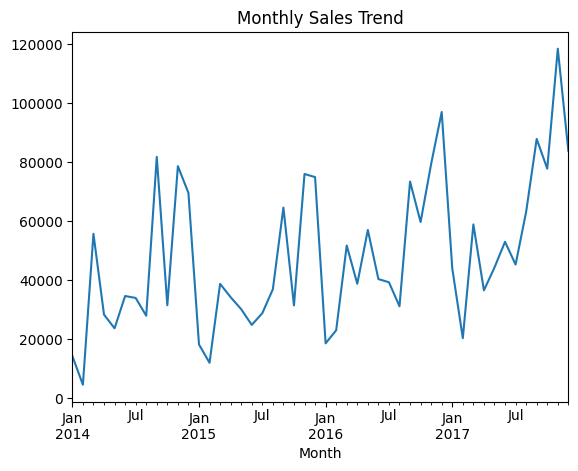

In [50]:
# GRAPHS 
# Monthly Sales Graph
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

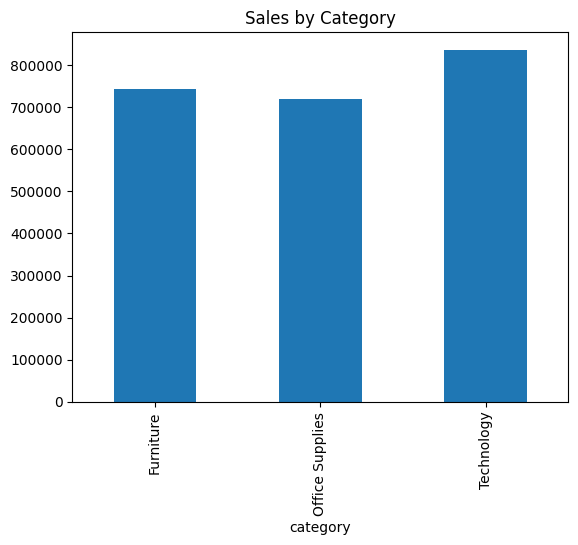

In [51]:
# Category Sales Bar Chart
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

In [ ]:
# Category Share Pie Chart
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Category Contribution")
plt.ylabel("")
plt.show()

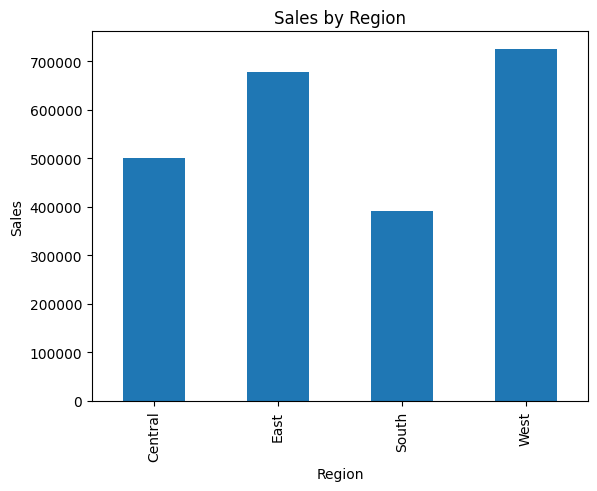

In [52]:
# Region-wise Sales Bar Chart
region_sales = df.groupby('region')['sales'].sum()

region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

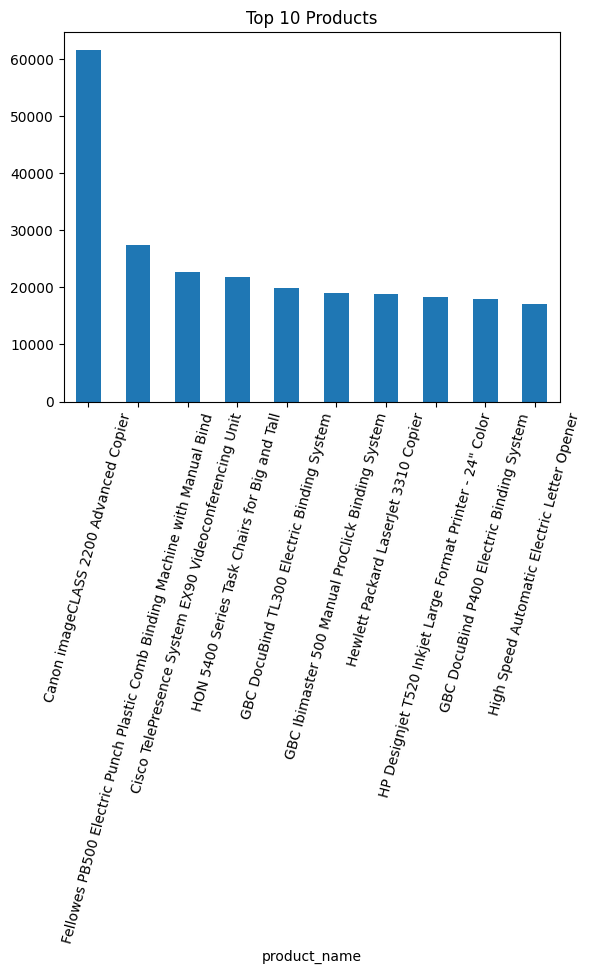

In [54]:
# Top 10 Products Bar Chart
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.xticks(rotation=75)
plt.show()

In [ ]:
# Delivery Time Analysis
# Delivery Time Analysis
df['delivery_Days'] = (df['ship_date'] - df['order_date']).dt.days

delivery = df.groupby('ship_mode')['delivery_Days'].mean()

delivery.plot(kind='bar')
plt.title("Average Delivery Days by Ship Mode")
plt.show()
df['delivery_Days'] = (df['ship date'] - df['order_date']).dt.days

delivery = df.groupby('Ship Mode')['delivery_Days'].mean()

delivery.plot(kind='bar')
plt.title("Average Delivery Days by Ship Mode")
plt.show()

KeyError: 'ship date'